<h1>Finding the Relative Difference (&Delta;) Between 8-DAY MODIS and VIIRS (NOAA21)<h1>

### Import packages

In [1]:
import os
import subprocess
from datetime import timezone
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from netCDF4 import Dataset

# added necessary packages
from dateutil.parser import parse
from datetime import timedelta, datetime
import xarray as xr
import pandas as pd

### Create global variables

In [2]:
ROOT_DIR = ("/Users/madisonrichardson/netpp")
VIIRS_DIR_T = os.path.join(ROOT_DIR, "data/{}/netpp/8_day_netpp")
SNPP_DIR = os.path.join(ROOT_DIR, "data/snpp_viirs/8_day/netpp")
MODIS_DIR = os.path.join(ROOT_DIR, "data/aqua_modis/8_day/netpp")
WORK_DIR = os.path.join(ROOT_DIR, 'work')
BIN_DIR = os.path.join(ROOT_DIR, 'bin')
RES_DIR = os.path.join(ROOT_DIR, 'resources')
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/matrix/delta")
CDL_IN_FILE = 'delta_nasa_8day_9k.cdl'
TEMP_OUT_FILE = 'tempoutfiledelta8day.nc'
NCO_DIR = '/Users/madisonrichardson/miniforge3/bin/'

<h3>Create function to generate a NetCDF file from a CDL file<h3>

In [3]:
def make_ncfile_from_cdl_dr(path_cdl, path_ncfile, nco_path):
    """
    Make a NetCDF file from a CDL (Common Data Language) file
    template using the ncgen tool.

    Args:
        path_cdl (str): The path to the input CDL file that defines
                        the structure of the NetCDF file.
        path_ncfile (str): The path to the output NetCDF file that
                            will be created by ncgen.
        nco_path (str): The path to the directory containing the
                        NCO (NetCDF Operators) tools such as ncgen
                        to make the NetCDF file from the CDL file.
    """
    myCmd = ' '.join([os.path.join(nco_path, 'ncgen'),
                      '-o', path_ncfile,
                      path_cdl])
    
    print("Generated NetCDF template",
          subprocess.call(myCmd, shell=True))  # prints zero if myCmd is success

<h3>Create function to find the relative difference (delta) between NOAA20 and MODIS NetPP datasets<h3>

In [4]:
def calculate_relative_diff(minuend_data, subtrahend_data):
    """
    Calculate the relative difference (delta) between the two
    datasets.

    Nerd Notation
    minuend is math-speak for the value substracted from.

    subtrahend is math-speak for the value that is substracted.

    Args:
        minuend_data (ma.MaskedArray): The dataset where values will be
                                    subtracted.
        subtrahend_data (ma.MaskedArray): The dataset that will be subtracted
                                        from 'minuend_data'.

    Returns:
        ma.MaskedArray: The array of relative difference values
                        where missing data remains masked.
    """

    # Calculate relative difference (delta)
    delta = ma.divide(ma.subtract(minuend_data, subtrahend_data), subtrahend_data)

    return delta

<h3>Create  function to populate a NetCDF file with a 3D matrix of the delta values <h3>

In [5]:
# Function to populate a single NetCDF file with delta values for all years and months

def get_nc_var_data_dr(file1_path, my_var):
    """
    Extract data from specified variable in a NetCDF file.

    Args:
        file1_path (str): The full path to the NetCDF file from
                            where the data is extracted.
        my_var (str): The name of the variable in the NetCDF file
                        to extract (e.g., 'productivity).

    Returns:
        netpp_file1 (numpy.ndarray): A 2D array (latitude, longitude) containing
        the data for the first time step of the specified variable.
    """
    
    file1 = Dataset(file1_path, 'r')

    # Extract NetPP data
    netpp_file1 = file1.variables[my_var][0, :, :]
    
    # Close the VIIRS and MODIS files
    file1.close()
    
    return netpp_file1

<h3>Run main function<h3>

In [ ]:
def main():
    """
    Runs main function.

    Raises:
        ValueError: If the dimensions of the VIIRS and MODIS
                    NetPP datasets do not match.
    """

    # Set the parameters for the code
    start_yr_mo = '2023-04-07'
    end_yr_mo = '2024-05-07'
    sensor = 'noaa21' # either 'noaa20' or 'noaa21'
    comparison_sensor ='modis' # either 'modis' or 'snpp_viirs'
    overwrite = False # Change to True if you want to overwrite existing NetCDF file

    start_date = parse(start_yr_mo)
    end_date = parse(end_yr_mo)
    print(start_date, end_date)

    # Define 8-day intervals
    day_step = timedelta(days=8)
    dates_to_bin = []
    current_date = start_date

    while current_date <= end_date:
        next_date = current_date + day_step

        # Check if the interval is Dec 27-31 and skip
        if (
            current_date.year == 2023
            and current_date.month == 12
            and current_date.day == 27
        ):
            print(f"Skipping interval from {current_date} to Dec 31")
            current_date = datetime(2024, 1, 1)
            continue

        # Add regular 8-day interval adjusting if it goes past Dec 31
        if next_date.year > current_date.year and current_date.month == 12:
            # Adjust to end on Dec 26 if it goes past the year
            end_dt = datetime(current_date.year, 12, 26)
        else:
            end_dt = next_date - timedelta(days=1)

        # Add the interval (start_date, end_date) to the list
        dates_to_bin.append((current_date, end_dt))

        # Move to the next interval
        current_date = next_date

    # Create dynamic directories and verify
    VIIRS_DIR = VIIRS_DIR_T.format(sensor)
    NC_OUT_DIR = NC_OUT_DIR_T.format(sensor)

    DIR_LIST = [ROOT_DIR,
                WORK_DIR,
                RES_DIR,
                VIIRS_DIR,
                SNPP_DIR,
                MODIS_DIR,
                NC_OUT_DIR,
                NCO_DIR
                ]

    for dr in DIR_LIST:
        os.makedirs(dr, exist_ok=True)
    print(len(DIR_LIST), 'directories validated')

    # Define the final output file path
    nc_filename = f'delta_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc'
    nc_file_path = os.path.join(NC_OUT_DIR, nc_filename)

    # Add logic to not overwrite existing files
    if os.path.isfile(nc_file_path):
        if not overwrite:
            print(f'{nc_filename} already exists for {sensor}')
        else:
            print(f'Overwriting {nc_filename} for {sensor}')

    # Generate the initial NetCDF template from CDL for all years
    make_ncfile_from_cdl_dr(os.path.join(RES_DIR, CDL_IN_FILE),
                            os.path.join(WORK_DIR, nc_file_path),
                            NCO_DIR
                            )

    # Name of variable in NetPP file
    netpp_var = 'productivity'

    nc_file = Dataset(nc_file_path, 'a', format='NETCDF4')

    time_index = 0
    for start_dt, end_dt in dates_to_bin:
        midpoint_dt = start_dt + timedelta(days=4)

        file_date = '{0:%Y%m%d}_{1:%Y%m%d}'.format(start_dt, end_dt)
        year = start_dt.year
        print("Processing", file_date)
 
        viirs_file_path = os.path.join(
            VIIRS_DIR,
            str(year),
            f"netpp_viirs_noaa21_8day_{file_date}.nc"
        )

        # Determine comparison file path based on selected comparison_sensor
        if comparison_sensor == 'modis':
            comparison_dir = MODIS_DIR
            comparison_file_path = os.path.join(
                comparison_dir,
                str(year),
                f"netpp_aqua_modis_8day_{file_date}.nc"
            )
        else:
            comparison_dir = SNPP_DIR
            comparison_file_path = os.path.join(
                comparison_dir,
                str(year),
                f"netpp_snpp_viirs_8day_{file_date}.nc"
            )

        if (
            not os.path.exists(viirs_file_path)
            or not os.path.exists(comparison_file_path)
        ):
            print(f"Files for {file_date} are missing! Skipping...")
            continue

        viirs_npp = get_nc_var_data_dr(viirs_file_path, netpp_var)
        comparison_npp = get_nc_var_data_dr(comparison_file_path, netpp_var)

        if viirs_npp.shape != comparison_npp.shape:
            err_msg = ("Dimension mismatch. Viirs shape: "
                       f"{viirs_npp.shape}, Legacy shape: "
                       f"{comparison_npp.shape}"
                       )
            raise ValueError(err_msg)
            print("Skipping...", file_date)
            continue

        delta = calculate_relative_diff(viirs_npp, comparison_npp)
        print('relative difference calculated for', file_date)

        time_stamp = midpoint_dt.replace(hour=0, minute=0, second=0).timestamp()
        nc_file['time'][time_index] = time_stamp
        nc_file['delta'][time_index, :, :] = delta[:, :]
        nc_file.title = (
            f"Pixel by pixel Delta, VIIRS {sensor.upper()} "
            f"minus {comparison_sensor.upper()}"
        )
        nc_file.summary = (
            f"The relative difference (Delta) between primary productivity "
            f"(NetPP) calculated using VIIRS {sensor.upper()} data and "
            f"{comparison_sensor.upper()} data. For each pixel, Delta is "
            f"calculated as netPP(VIIRS {sensor.upper()}) - "
            f"netPP({comparison_sensor.upper()}) divided by "
            f"netPP({comparison_sensor.upper()}). Primary productivity was"
            f" calculated as described by Behrenfeld and Falkowski 1997. "
            f"The data is a 1-year mean from Apr 2023 to May 2024 and "
            f"at 9km resolution. Input data for primary productivity were "
            f"obtained from NASA and included chlorophyll_a, sea surface "
            f"temperature, and photosynthetically active radiation from "
            f"either {comparison_sensor.upper()} or {sensor.upper()}."
        )
        nc_file.sync()
        print(file_date, 'data saved to nc file')

        time_index += 1

    nc_file.close()

    # Compress file with nccopy
    compressed_nc_file_path = os.path.join(
        NC_OUT_DIR,
        'compressed_' + nc_filename
    )

    compressed_cmd = ' '.join(
        [
            'nccopy',
            '-d4',
            nc_file_path,
            compressed_nc_file_path
        ]
    )
    print('Compress ofile', subprocess.call(compressed_cmd, shell=True))

    archive_cmd = ' '.join(['mv', compressed_nc_file_path, nc_file_path])
    print('Archive ofile', subprocess.call(archive_cmd, shell=True))

    print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")


if __name__ == '__main__':
    main()


2023-04-07 00:00:00 2024-05-07 00:00:00
Skipping interval from 2023-12-27 00:00:00 to Dec 31
8 directories validated
Generated NetCDF template 0
Processing 20230407_20230414
relative difference calculated for 20230407_20230414
20230407_20230414 data saved to nc file
Processing 20230415_20230422


/var/folders/81/qj7mv_yn7p98wpb9n0np6q8c0000gn/T/ipykernel_12175/2426247523.py:146: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  nc_file['delta'][time_index, :, :] = delta[:, :]


relative difference calculated for 20230415_20230422
20230415_20230422 data saved to nc file
Processing 20230423_20230430
relative difference calculated for 20230423_20230430
20230423_20230430 data saved to nc file
Processing 20230501_20230508
relative difference calculated for 20230501_20230508
20230501_20230508 data saved to nc file
Processing 20230509_20230516
relative difference calculated for 20230509_20230516
20230509_20230516 data saved to nc file
Processing 20230517_20230524
relative difference calculated for 20230517_20230524
20230517_20230524 data saved to nc file
Processing 20230525_20230601
relative difference calculated for 20230525_20230601
20230525_20230601 data saved to nc file
Processing 20230602_20230609
relative difference calculated for 20230602_20230609
20230602_20230609 data saved to nc file
Processing 20230610_20230617
relative difference calculated for 20230610_20230617
20230610_20230617 data saved to nc file
Processing 20230618_20230625
relative difference calc

<h2> Calculate and plot monthly means for Relative Difference<h2>

<h3>Monthly mean, minimum, and maximum values of delta using xarray<h3>

In [7]:
sensor = 'noaa21'
comparison_sensor = 'modis'
delta_matrix_file = (
    f"{ROOT_DIR}/data/{sensor}/matrix/delta/"
    f"delta_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc"
)
ds = xr.open_dataset(delta_matrix_file)
da = ds.delta

delta_mean3 = da.mean(dim=["latitude", "longitude"], skipna=True)
delta_max = da.max(dim=["latitude", "longitude"], skipna=True)
delta_min = da.min(dim=["latitude", "longitude"], skipna=True)

my_date = pd.to_datetime(da.time.values)

for i in range(0, my_date.size):
    print('For', '{0:%B %Y}'.format(my_date[i]))
    print(
        f"Mean relative difference {delta_mean3[0]:.2f}",
        f"Min relative difference {delta_min[0]:.2f}",
        f"Max relative difference {delta_max[0]:.2f}"
    )

For April 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For April 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For April 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For May 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For May 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For May 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For May 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For June 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For June 2023
Mean relative difference 0.14 Min relative difference -0.95 Max relative difference 19.70
For June 2023
Mean relative difference 0.14 Min relative differen

<h3>Generate monthly means and plot monthly mean timeseries<h3>

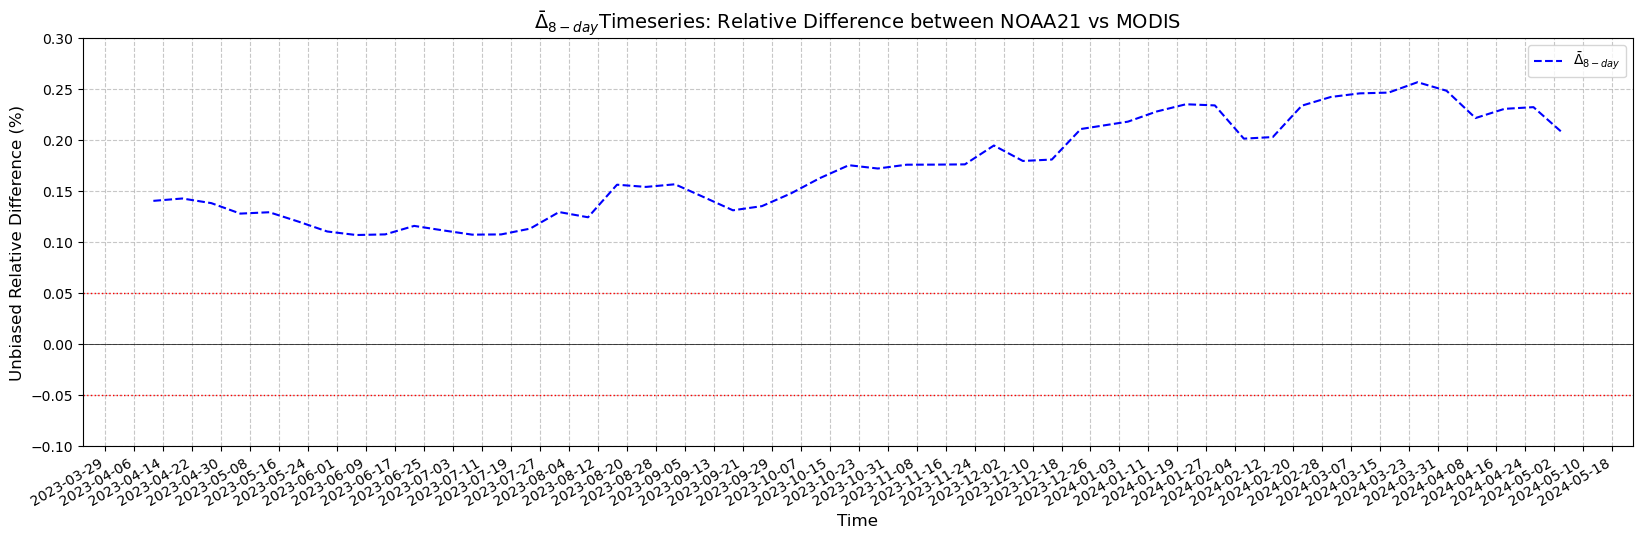

In [8]:
# Open the NetCDF file
sensor = 'noaa21'
comparison_sensor = 'modis'
delta_matrix_file = (
    f"{ROOT_DIR}/data/{sensor}/matrix/delta/"
    f"delta_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc"
)
ds = xr.open_dataset(delta_matrix_file)
da = ds.delta

# Calculate mean delta for each 8-day composite period
delta_mean_composite = da.mean(dim=["latitude", "longitude"], skipna=True)

# Convert time values explicitly to DateTimeIndex
time_index = pd.to_datetime(delta_mean_composite.time.values)

# Create plot
plt.figure(figsize=(20, 6))
plt.plot(time_index, delta_mean_composite, 'b--', label=r'$\bar{\Delta}_{8-day}$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(0.05, color='red', linestyle=':', linewidth='1')
plt.axhline(-0.05, color='red', linestyle=':', linewidth='1')
plt.ylim(-0.1, 0.3)

# Add titles and labels
plt.title(
    r'$\bar{\Delta}_{8-day}$' f'Timeseries: Relative Difference between '
    f'{sensor.upper()} vs {comparison_sensor.upper()}',
    fontsize=14
)
plt.ylabel('Unbiased Relative Difference (%)', fontsize=12)
plt.xlabel('Time', fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=8))  # Major ticks every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format as 'Year Month 

# Formatting the x-axis to be able to read easily
plt.gcf().autofmt_xdate()

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.legend()
plt.show()

<h2> Calculate and Plot Spatial Variability<h2>

<h3>Generate and plot Delta 5-year global map<h3>

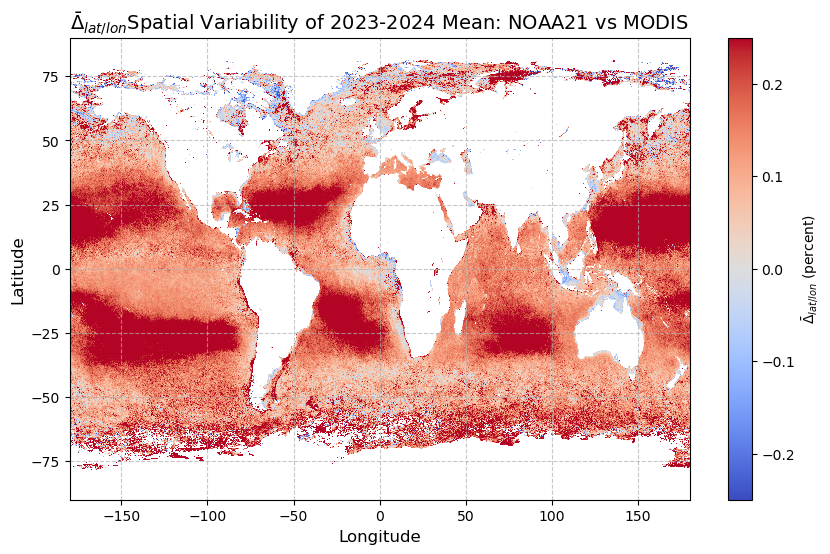

In [9]:
sensor = 'noaa21'
comparison_sensor = 'modis'
delta_matrix_file = (
    f"{ROOT_DIR}/data/{sensor}/matrix/delta/"
    f"delta_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc"
)
ds = xr.open_dataset(delta_matrix_file)
da = ds.delta

# Center time on the 5th day of the each 8-day composite period
time_centered = pd.to_datetime(da.time.values)
time_centered = time_centered.map(lambda x: x.replace(day=5))

# Assign the centered time back to the dataset
da['time'] = time_centered

delta_mean = da.mean(dim="time", skipna=True).values

# Plot the spatial variability as a 2D Map
plt.figure(figsize=(10, 6))

# Use color with a range from -20% to 20%
plt.pcolormesh(ds.longitude, ds.latitude, delta_mean, cmap='coolwarm', vmin=-.25, vmax=.25)

# Add a colorbar
cbar = plt.colorbar()
cbar.set_label(r'$\bar{\Delta}_{lat/lon}$ (percent)')

# Add labels and title
plt.title(
    r'$\bar{\Delta}_{lat/lon}$'
    f'Spatial Variability of 2023-2024 Mean: '
    f'{sensor.upper()} vs {comparison_sensor.upper()}',
    fontsize=14
)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()